In [2]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *

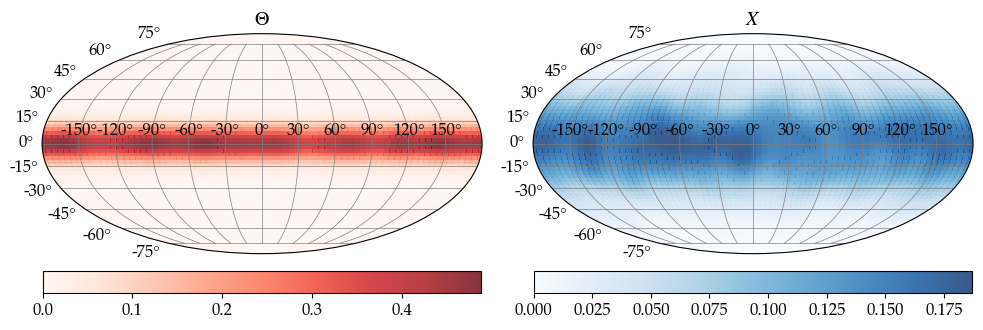

In [ ]:
manifold_type = 'S2' ; manifold = get_manifold(manifold_type)
n_samples = 5000
# prior param
num_modes = 5; tau2 = 5e-2; sigma2 = .15
# G = lambda n: multimodal_sampler(manifold_type, n, tau2, num_modes) 
G = lambda n: equator_sampler(manifold_type, n, .00001)
# get data
Theta = G(n_samples)
X = manifold.random_riemannian_normal(Theta, 1./(sigma2), n_samples)
# display data
if True:
    fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection': 'mollweide'})
    grid_resolution = 75
    grid, grid_theta, grid_phi = S2grid(grid_resolution)
    densities = [kernel_density_estimate('S2', data, grid, 50)[1].reshape(grid_resolution, grid_resolution) for data in [Theta, X]]
    vmax = None #max([d.max() for d in densities])
    for hat_f, ax, title, cmap in zip(densities, axs, ['$\\Theta$', '$X_i$', 'Denoised $X_i$'], ['Reds', 'Blues', 'Greens']):
        im = ax.pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f,
                        alpha=0.8, shading='auto', cmap=cmap, vmin=0, vmax=vmax)
        fig.colorbar(im, ax=ax, orientation='horizontal', fraction=0.05, pad=0.04)
        ax.grid(True, color='gray', lw=0.5)
        ax.set_title(title)
    plt.tight_layout(); plt.show()


Folds: 100%|██████████| 10/10 [00:44<00:00,  4.41s/it]


5 0.06657640787494053


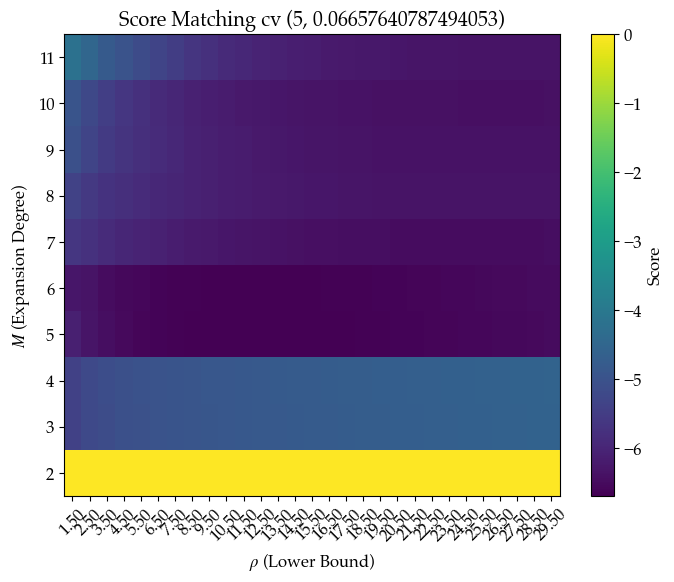

In [41]:

# crossvalidation (score matching) for parameter selection
M_grid=np.arange(2, 12)
rho_perc = np.arange(1.5,30,1)
criterion = 'cv'
params_scoreMatching , cv_scores_scoreMatching =  scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_perc, n_splits=10, return_scores=True, random_state=42)
plot_cv_scores(cv_scores_scoreMatching[criterion], M_grid, rho_perc, title=f"Score Matching cv {params_scoreMatching[criterion]}")
M,rho = params_scoreMatching[criterion]
print(M,rho)


In [48]:
# --- empirical denoiser
delta = denoiser(manifold_type, X, M, rho, sigma2, X)

# oracle denoiser
num_oracle_samples = 10000
oracle_delta_T = oracle_denoiser(manifold_type, num_oracle_samples, sigma2, X, n_bins = 1000, G = G)

# --- losses
loss_N = sq_loss(manifold, X, Theta)
loss_T = sq_loss(manifold, delta, Theta) 
loss_oracle_T = sq_loss(manifold, oracle_delta_T, Theta) 
print(f"Loss N: {loss_N:.4f}, Loss T: {loss_T:.4f}, Loss oracle T: {loss_oracle_T:.4f}")
print(f'Excess loss: {loss_T - loss_oracle_T:.4f}')

Loss N: 0.2786, Loss T: 0.1771, Loss oracle T: 0.1689
Excess loss: 0.0082


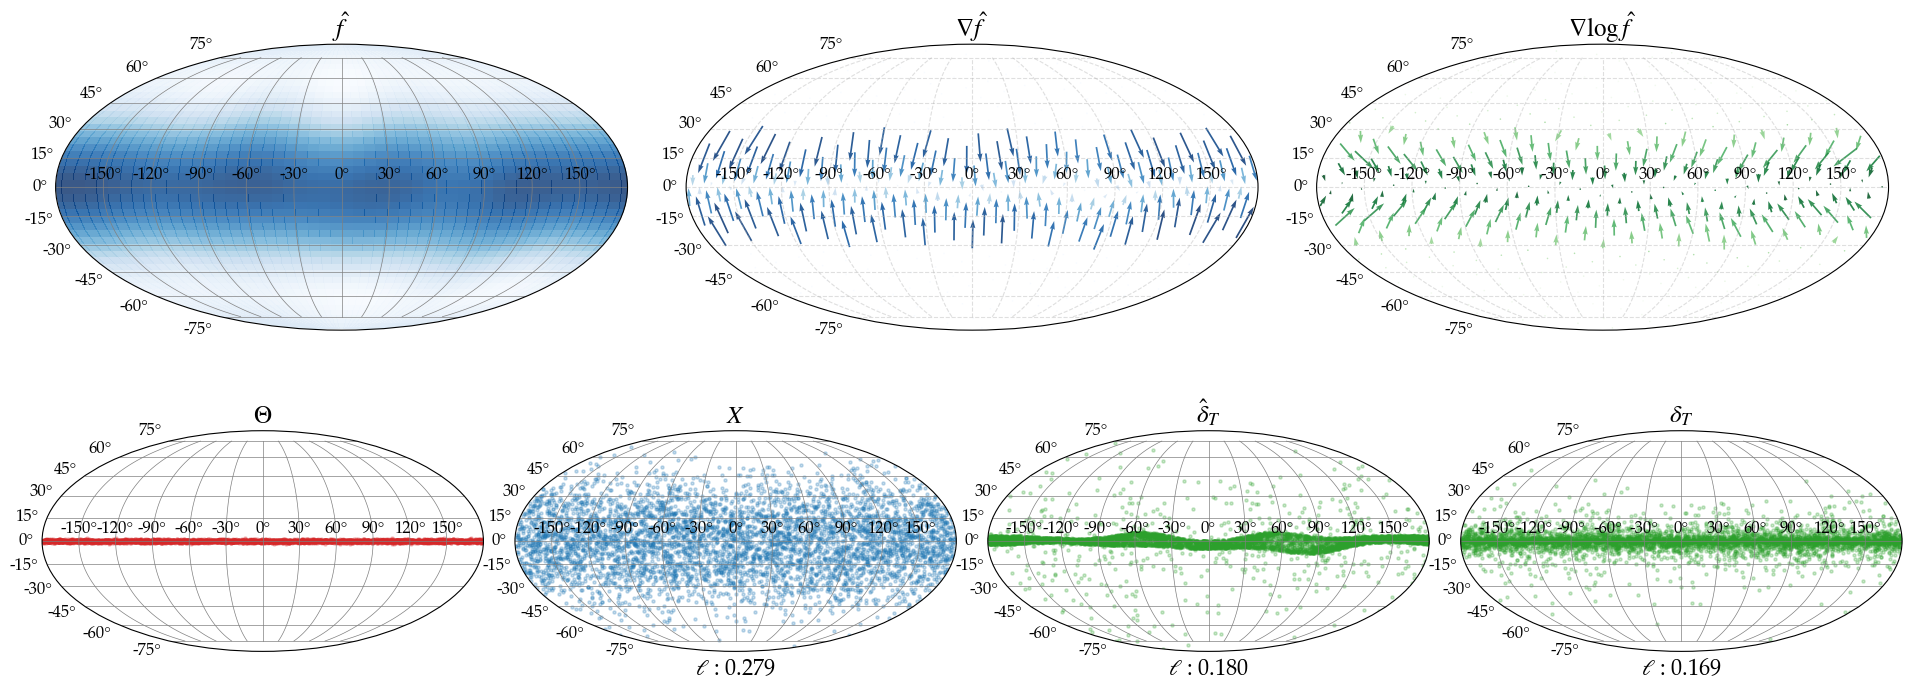

In [ ]:
alpha = .2
grid_size  = 50
first_row = True
second_row = True
if first_row or second_row:
    fig = plt.figure(figsize=(24, 8))
    gs = fig.add_gridspec(2, 12, height_ratios=[1.2, 1.0], hspace=0.35, wspace=0.25)
# ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
if first_row:
    # Row 1: 3 larger polar plots (each spans 4/12 columns)
    axs_top = [fig.add_subplot(gs[0, 0:4], projection='mollweide'),
            fig.add_subplot(gs[0, 4:8], projection='mollweide'),
            fig.add_subplot(gs[0, 8:12], projection='mollweide')]

    grid_resolution = 50
    grid, grid_theta, grid_phi = S2grid(grid_resolution)
    _, hat_f, hat_grad_f, = density_estimate('S2', X, M, grid)
    hat_grad_f = np.where(hat_f[:, None] > rho, hat_grad_f, np.zeros_like(hat_grad_f))
    im = axs_top[0].pcolormesh( grid_phi - np.pi, np.pi/2 - grid_theta, hat_f.reshape(grid_resolution,grid_resolution), alpha=0.8, shading='auto', cmap='Blues')
    axs_top[0].grid(True, color='gray', lw=0.5)

    grid_resolution = 20
    grid, grid_theta, grid_phi = S2grid_fib(grid_resolution)
    _, hat_f, hat_grad_f, = density_estimate('S2', X, M, grid)
    hat_grad_f = np.where(hat_f[:, None] > rho, hat_grad_f, np.zeros_like(hat_grad_f))
    _score = hat_grad_f/np.maximum(hat_f, rho)[:, None]
    vals_to_plot =  {   'gradient': {'vals': hat_grad_f, 'cmap' : 'Blues', 'title' : r'$\nabla \hat f$' },
                        'score': {'vals': _score, 'cmap' : 'Greens', 'title' : r'$\nabla \log \hat f$' }}
    WHICH = 'gradient'
    S2plot_quiver(grid , vals_to_plot[WHICH]['vals'], figax= (fig,axs_top[1]), scale=1, cmap = vals_to_plot[WHICH]['cmap'])
    WHICH = 'score'
    S2plot_quiver(grid , vals_to_plot[WHICH]['vals'], figax= (fig,axs_top[2]), scale=10, cmap = vals_to_plot[WHICH]['cmap'], cvals = hat_f)

    axs_top[0].set_title('$\hat f$', fontsize=18)
    axs_top[1].set_title(vals_to_plot['gradient']['title'], fontsize=18)
    axs_top[2].set_title(vals_to_plot['score']['title'], fontsize=18)

# ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
if second_row:
    # Row 2: 4 polar plots (each spans 3/12 columns)
    axs_bottom = [fig.add_subplot(gs[1, 0:3], projection='mollweide'),
                fig.add_subplot(gs[1, 3:6], projection='mollweide'),
                fig.add_subplot(gs[1, 6:9], projection='mollweide'),
                fig.add_subplot(gs[1, 9:12], projection='mollweide')]
    # ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ---- ----
    for ax, data,  title, loss, c, cmap in zip(axs_bottom,
                                    [Theta, X, delta, oracle_delta_T],
                                    ['$\Theta$', '$X_i$', '$\hat\delta_{\mathcal{T}}$', '$\delta_{\mathcal{T}}$', '$\delta_B$'],
                                    [None, loss_N, loss_T, loss_oracle_T],
                                    ['C3', 'C0', 'C2', 'C2', 'C4'],
                                    ['Reds', 'Blues', 'Greens', 'Greens']):  
        S2scatter(data, ax, color=c, alpha=0.25)
        ax.set_title(fr'{title}', fontsize=18)
        if loss is not None:
            ax.set_xlabel(rf'$\ell$ : {loss:.3f}', fontsize=16)
plt.show()

    # print('Excess risk : ', loss_T - loss_oracle_T)
# fig.savefig(f"../fig/denoising_S2.png", bbox_inches='tight')